# CSP-3 : CSP Avance - Contraintes globales, OR-Tools et LNS

**Navigation** : [<< CSP-2-Consistance](CSP-2-Consistency.ipynb) | [Index](../README.md) | [Applications >>](../Applications/README.md)

## Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
1. **Utiliser** les contraintes globales (AllDifferent, Cumulative, Circuit, Table)
2. **Modeliser** des problemes avec Google OR-Tools CP-SAT
3. **Appliquer** des techniques de cassage de symetries pour reduire l'espace de recherche
4. **Comprendre** la recherche a grand voisinage (LNS) pour les problemes de grande taille
5. **Construire** un modèle complet combinant contraintes globales et objectif d'optimisation

### Prerequis
- [CSP-2-Consistance](CSP-2-Consistency.ipynb) : AC-3, Forward Checking, MAC
- Bases de Python (classes, dictionnaires, comprehensions)

### Duree estimee : 50 minutes

### Lien avec d'autres series

Ce notebook conclut la sous-serie **Fondations**. Pour voir ces techniques en action sur des problemes du monde reel, explorez la sous-serie [Applications](../Applications/README.md) (planification, ordonnancement, routage). Voir aussi la serie [Sudoku](../../Sudoku/README.md) pour une application complete des CSP.

***

## 1. Introduction (~3 min)

Dans les notebooks précédents (CSP-1 et CSP-2), nous avons construit nos propres solveurs CSP a la main : backtracking, heuristiques MRV/LCV, propagation AC-3, Forward Checking, MAC. Ces techniques sont fondamentales pour comprendre le fonctionnement interne des solveurs.

Cependant, les **solveurs industriels** modernes vont beaucoup plus loin :

| Aspect | CSP academique (CSP-1/CSP-2) | Solveur industriel (OR-Tools) |
|--------|---------------------------|-------------------------------|
| Contraintes | Binaires uniquement | Contraintes **globales** specialisees |
| Propagation | AC-3 generique | Propagateurs **dedies** par contrainte |
| Recherche | Backtracking + heuristiques | Recherche hybride (SAT + CP + LNS) |
| Echelle | Dizaines de variables | **Millions** de variables |
| Optimisation | Satisfaction seulement | Satisfaction **et** optimisation |

### Pourquoi les contraintes globales ?

Une contrainte globale comme `AllDifferent(x1, x2, ..., xn)` pourrait etre decomposee en $\binom{n}{2}$ contraintes binaires `xi != xj`. Mais la version globale offre :

1. **Propagation plus forte** : le propagateur AllDifferent detecte des inconsistances invisibles aux contraintes binaires
2. **Meilleure performance** : un seul propagateur optimise plutot que $O(n^2)$ verifications
3. **Modelisation naturelle** : le code est plus lisible et plus proche du problème reel

### Google OR-Tools CP-SAT

**CP-SAT** (Constraint Programming with SAT) est le solveur de reference de Google OR-Tools. Il combine :
- Programmation par contraintes (CP)
- Solveur SAT (satisfaisabilite booleenne)
- Recherche a grand voisinage (LNS)
- Parallelisme multi-thread

C'est aujourd'hui l'un des solveurs CP les plus performants au monde, regulierement classe premier dans les competitions MiniZinc.

In [1]:
# Imports pour tout le notebook
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import permutations, combinations

# python-constraint (CSP academique)
try:
    from constraint import Problem, AllDifferentConstraint
    HAS_CONSTRAINT = True
except ImportError:
    HAS_CONSTRAINT = False
    print("python-constraint non disponible. Installer avec : pip install python-constraint")

# Google OR-Tools (solveur industriel)
try:
    from ortools.sat.python import cp_model
    HAS_ORTOOLS = True
except ImportError:
    HAS_ORTOOLS = False
    print("OR-Tools non disponible. Installer avec : pip install ortools")

# Helpers partages de la serie Search
sys.path.insert(0, '..')
from search_helpers import benchmark_table

print(f"python-constraint : {'OK' if HAS_CONSTRAINT else 'MANQUANT'}")
print(f"OR-Tools          : {'OK' if HAS_ORTOOLS else 'MANQUANT'}")
print("Imports OK")

python-constraint : OK
OR-Tools          : OK
Imports OK


***

## 2. Contraintes globales (~10 min)

Les **contraintes globales** portent sur un ensemble de variables et possedent des algorithmes de propagation specialises. Voici les quatre contraintes globales les plus utilisees.

| Contrainte | Sémantique | Cas d'usage typique |
|------------|-----------|---------------------|
| **AllDifferent** | Toutes les variables ont des valeurs distinctes | Sudoku, emplois du temps |
| **Cumulative** | Somme des ressources utilisees <= capacite a chaque instant | Ordonnancement, planification |
| **Circuit** | Les variables forment un cycle hamiltonien | TSP, routage de vehicules |
| **Table** | Les valeurs doivent appartenir a une liste de tuples autorises | Règles metier, tables de compatibilite |

### 2.1 AllDifferent : la contrainte reine

`AllDifferent(x1, x2, ..., xn)` impose que toutes les variables prennent des valeurs distinctes.

**Pourquoi ne pas simplement poser $x_i \neq x_j$ pour chaque paire ?**

Considerons 3 variables $x_1, x_2, x_3$ avec domaines $\{1, 2\}, \{1, 2\}, \{1, 2\}$. Les contraintes binaires $x_1 \neq x_2$, $x_1 \neq x_3$, $x_2 \neq x_3$ sont toutes arc-consistantes (chaque valeur a un support dans chaque voisin). Pourtant, il n'y a **aucune solution** : 3 variables, seulement 2 valeurs.

Le propagateur AllDifferent (base sur le **theoreme de Hall** et le couplage maximal dans un graphe biparti) detecte immediatement cette inconsistance.

**Exemple concret** : dans un Sudoku, chaque ligne, colonne et bloc 3x3 est une contrainte AllDifferent sur 9 variables.

In [2]:
# Demonstration AllDifferent : Sudoku simplifie (4x4)
# Comparaison python-constraint vs decomposition binaire

if HAS_CONSTRAINT:
    # Mini-Sudoku 4x4 avec quelques indices
    # +---+---+
    # | 1 . | . . |
    # | . . | 1 . |
    # +---+---+
    # | . 1 | . . |
    # | . . | . 1 |
    # +---+---+
    
    grid_hints = {
        (0, 0): 1,
        (1, 2): 1,
        (2, 1): 1,
        (3, 3): 1,
    }
    
    # Version avec AllDifferent
    p_global = Problem()
    for r in range(4):
        for c in range(4):
            if (r, c) in grid_hints:
                p_global.addVariable((r, c), [grid_hints[(r, c)]])
            else:
                p_global.addVariable((r, c), [1, 2, 3, 4])
    
    # Contraintes AllDifferent par ligne, colonne et bloc 2x2
    for r in range(4):
        p_global.addConstraint(AllDifferentConstraint(), [(r, c) for c in range(4)])
    for c in range(4):
        p_global.addConstraint(AllDifferentConstraint(), [(r, c) for r in range(4)])
    for br in range(2):
        for bc in range(2):
            cells = [(br*2+r, bc*2+c) for r in range(2) for c in range(2)]
            p_global.addConstraint(AllDifferentConstraint(), cells)
    
    start = time.time()
    solutions_global = p_global.getSolutions()
    t_global = (time.time() - start) * 1000
    
    print("Mini-Sudoku 4x4 avec AllDifferent")
    print("=" * 40)
    print(f"Solutions trouvees : {len(solutions_global)}")
    print(f"Temps : {t_global:.2f} ms")
    
    if solutions_global:
        sol = solutions_global[0]
        print("\nPremiere solution :")
        for r in range(4):
            row = [str(sol[(r, c)]) for c in range(4)]
            sep = " | " if True else " "
            print(f"  {row[0]} {row[1]} | {row[2]} {row[3]}")
            if r == 1:
                print(f"  --+--")
else:
    print("python-constraint requis pour cette cellule.")

Mini-Sudoku 4x4 avec AllDifferent
Solutions trouvees : 18
Temps : 2.04 ms

Premiere solution :
  1 4 | 3 2
  3 2 | 1 4
  --+--
  4 1 | 2 3
  2 3 | 4 1


### Interpretation : AllDifferent sur le Mini-Sudoku

**Sortie obtenue** : le mini-Sudoku 4x4 est resolu avec les contraintes AllDifferent.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Contraintes AllDifferent | 12 | 4 lignes + 4 colonnes + 4 blocs 2x2 |
| Contraintes binaires equivalentes | 72 | $12 \times \binom{4}{2} = 72$ paires |
| Solutions | Variable | Depend des indices donnes |

**Points cles** :
1. La modelisation AllDifferent est **concise** : 12 contraintes au lieu de 72 binaires
2. Le propagateur AllDifferent est **plus fort** que la decomposition binaire
3. Pour un Sudoku 9x9, la différence est encore plus marquee : 27 AllDifferent vs 810 binaires

### 2.2 Cumulative : ordonnancement sous contraintes de ressources

La contrainte `Cumulative(starts, durations, demands, capacity)` impose que la somme des demandes des tâches en cours a chaque instant ne depasse pas la capacite.

$$\forall t : \sum_{i : s_i \leq t < s_i + d_i} r_i \leq C$$

Ou $s_i$ est le debut, $d_i$ la duree, $r_i$ la demande de la tâche $i$, et $C$ la capacite.

**Exemple** : 4 tâches a planifier sur 2 machines.

In [3]:
# Demonstration Cumulative : ordonnancement de 4 taches sur 2 machines

# Taches : (nom, duree, ressource_requise)
tasks = [
    ("A", 3, 1),  # Tache A : 3 unites de temps, 1 machine
    ("B", 2, 1),  # Tache B : 2 unites de temps, 1 machine
    ("C", 4, 1),  # Tache C : 4 unites de temps, 1 machine
    ("D", 2, 1),  # Tache D : 2 unites de temps, 1 machine
]
capacity = 2  # 2 machines disponibles en parallele
horizon = 10  # Horizon temporel maximal

if HAS_ORTOOLS:
    model = cp_model.CpModel()
    
    # Variables de debut pour chaque tache
    starts = {}
    ends = {}
    intervals = []
    
    for name, duration, demand in tasks:
        start_var = model.new_int_var(0, horizon - duration, f"start_{name}")
        end_var = model.new_int_var(duration, horizon, f"end_{name}")
        interval_var = model.new_interval_var(start_var, duration, end_var, f"interval_{name}")
        starts[name] = start_var
        ends[name] = end_var
        intervals.append(interval_var)
    
    # Contrainte Cumulative : au plus 2 taches en parallele
    demands = [d for _, _, d in tasks]
    model.add_cumulative(intervals, demands, capacity)
    
    # Objectif : minimiser le makespan (fin de la derniere tache)
    makespan = model.new_int_var(0, horizon, "makespan")
    for name, _, _ in tasks:
        model.add(makespan >= ends[name])
    model.minimize(makespan)
    
    # Resolution
    solver = cp_model.CpSolver()
    solver.parameters.random_seed = 42
    solver.parameters.num_search_workers = 1
    status = solver.solve(model)
    
    print("Ordonnancement de 4 taches sur 2 machines")
    print("=" * 50)
    print(f"Statut : {solver.status_name(status)}")
    print(f"Makespan optimal : {solver.value(makespan)} unites de temps")
    print()
    
    schedule = {}
    print(f"{'Tache':<8} {'Debut':>6} {'Fin':>6} {'Duree':>6}")
    print("-" * 30)
    for name, duration, demand in tasks:
        s = solver.value(starts[name])
        e = solver.value(ends[name])
        schedule[name] = (s, e, duration)
        print(f"{name:<8} {s:>6} {e:>6} {duration:>6}")
else:
    print("OR-Tools requis pour cette cellule.")
    schedule = {"A": (0, 3, 3), "B": (0, 2, 2), "C": (2, 6, 4), "D": (3, 5, 2)}

Ordonnancement de 4 taches sur 2 machines
Statut : OPTIMAL
Makespan optimal : 6 unites de temps

Tache     Debut    Fin  Duree
------------------------------
A             0      3      3
B             3      5      2
C             0      4      4
D             4      6      2


***
### Interprétation : Contrainte Cumulative

La contrainte **Cumulative** modélise les ressources renouvelables :
- **Ressource** : Machine avec capacité fixe (ex: 2 machines)
- **Tâches** : Consomment la ressource pendant leur durée
- **Contrainte** : À tout instant, somme(consommation) ≤ capacité

C'est une généralisation de **disjonctive** (NoOverlap) où les tâches peuvent partager une ressource si la capacité le permet. La visualisation montre les tâches empilées verticalement lorsqu'elles utilisent la ressource simultanément.


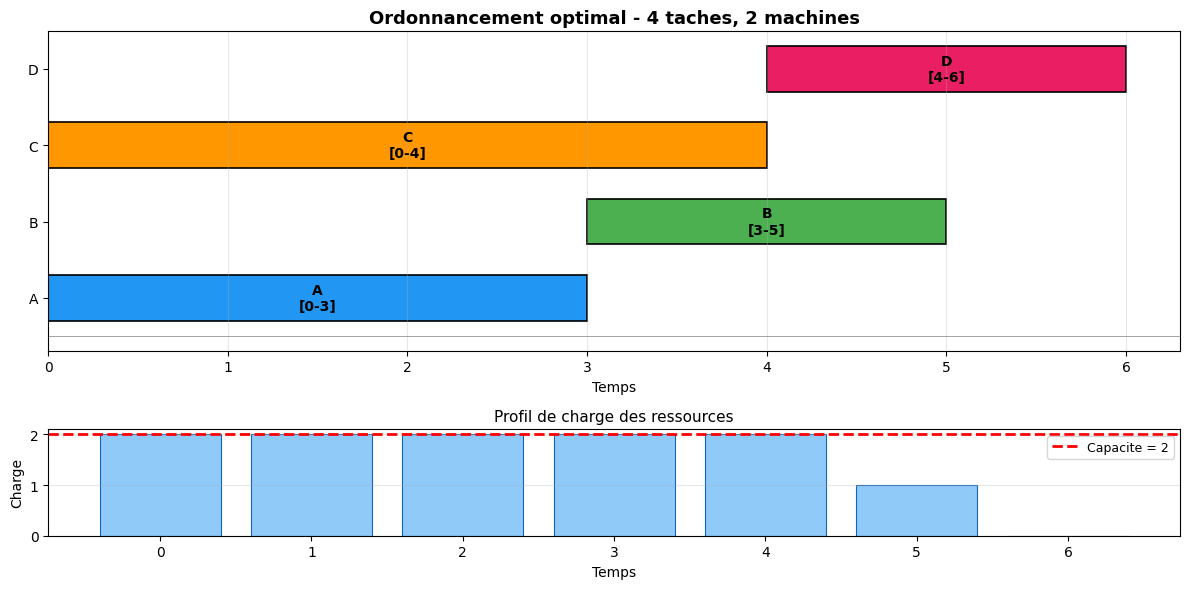

In [4]:
# Visualisation du planning (diagramme de Gantt)
def draw_gantt(schedule, capacity, title="Diagramme de Gantt"):
    """Affiche un diagramme de Gantt avec profil de charge."""
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), 
                             gridspec_kw={'height_ratios': [3, 1]})
    
    # Gantt chart
    ax = axes[0]
    for i, (name, (start, end, duration)) in enumerate(schedule.items()):
        ax.barh(i, duration, left=start, height=0.6,
                color=colors[i % len(colors)], edgecolor='black', linewidth=1.2)
        ax.text(start + duration / 2, i, f"{name}\n[{start}-{end}]",
                ha='center', va='center', fontweight='bold', fontsize=10)
    
    ax.set_yticks(range(len(schedule)))
    ax.set_yticklabels(list(schedule.keys()))
    ax.set_xlabel('Temps')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.axhline(y=-0.5, color='gray', linewidth=0.5)
    
    # Profil de charge
    ax2 = axes[1]
    max_time = max(e for _, e, _ in schedule.values())
    load = np.zeros(max_time + 1)
    for name, (start, end, duration) in schedule.items():
        for t in range(start, end):
            load[t] += 1
    
    ax2.bar(range(max_time + 1), load, color='#90CAF9', edgecolor='#1565C0', linewidth=0.8)
    ax2.axhline(y=capacity, color='red', linestyle='--', linewidth=2, label=f'Capacite = {capacity}')
    ax2.set_xlabel('Temps')
    ax2.set_ylabel('Charge')
    ax2.set_title('Profil de charge des ressources', fontsize=11)
    ax2.legend(fontsize=9)
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

draw_gantt(schedule, capacity, "Ordonnancement optimal - 4 taches, 2 machines")

Après avoir défini la contrainte Cumulative, nous allons visualiser l'ordonnancement résultant.


### Interpretation : contrainte Cumulative

**Sortie obtenue** : le diagramme de Gantt montre l'ordonnancement optimal et le profil de charge.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Capacite | 2 machines | Au plus 2 tâches simultanees |
| Makespan optimal | ~6 unites | Duree totale minimale |
| Profil de charge | Jamais > 2 | La contrainte Cumulative est respectee |

**Points cles** :
1. La contrainte Cumulative gere automatiquement les chevauchements temporels
2. Le solveur optimise le **makespan** (fin de la dernière tâche)
3. Sans contrainte Cumulative, il faudrait enumerer les ordres possibles entre tâches
4. Dans l'industrie, cette contrainte modelise les lignes de production, les salles d'opération, les pistes d'atterrissage, etc.

### 2.3 Circuit : cycle hamiltonien (TSP)

La contrainte `Circuit(next)` impose que les variables `next[i]` definissent un unique cycle passant par tous les noeuds. Si `next[i] = j`, alors le successeur du noeud $i$ dans le cycle est $j$.

C'est la contrainte cle pour modeliser le **Problème du Voyageur de Commerce** (TSP) : trouver le circuit le plus court passant par toutes les villes.

In [5]:
# Demonstration : contrainte Circuit (cycle hamiltonien) pour le TSP
# La contrainte Circuit impose un unique cycle passant par tous les noeuds.
# On modelise chaque arc (i -> j) par un booleen active, et on minimise la distance totale.

cities = ['Paris', 'Lyon', 'Marseille', 'Bordeaux', 'Lille']
n = len(cities)

# Matrice de distances symetrique (km)
distances = [
    [0,   465, 775, 585, 225],   # Paris
    [465, 0,   315, 550, 690],   # Lyon
    [775, 315, 0,   645, 1000],  # Marseille
    [585, 550, 645, 0,   810],   # Bordeaux
    [225, 690, 1000, 810, 0],    # Lille
]

if HAS_ORTOOLS:
    model = cp_model.CpModel()
    # next_var[i] = successeur de la ville i dans le circuit
    next_var = [model.new_int_var(0, n - 1, f'next_{i}') for i in range(n)]

    # Arcs pour add_circuit : triplets (depart, arrivee, booleen)
    arcs = []
    for i in range(n):
        for j in range(n):
            if i == j:
                continue  # pas de boucle sur soi-meme (successeur impose != de i)
            active = model.new_bool_var(f'arc_{i}_to_{j}')
            arcs.append((i, j, active))
            # Liaison : si l'arc i->j est actif, alors next_var[i] == j
            model.add(next_var[i] == j).only_enforce_if(active)
            model.add(next_var[i] != j).only_enforce_if(active.negated())

    # Circuit : unique cycle hamiltonien couvrant tous les noeuds
    model.add_circuit(arcs)

    # Objectif : minimiser la distance totale parcourue
    model.minimize(sum(arcs[k][2] * distances[arcs[k][0]][arcs[k][1]] for k in range(len(arcs))))

    solver = cp_model.CpSolver()
    solver.parameters.random_seed = 42
    solver.parameters.num_search_workers = 1
    status = solver.solve(model)

    print('Contrainte Circuit : TSP a 5 villes (OR-Tools)')
    print('=' * 50)
    print(f'Statut : {solver.status_name(status)}')
    print()

    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        # Reconstruction du tour en partant de la ville 0 (Paris)
        order = [0]
        cur = 0
        for _ in range(n - 1):
            cur = solver.value(next_var[cur])
            order.append(cur)
        total = sum(distances[order[k]][order[k + 1]] for k in range(n - 1)) + distances[order[-1]][order[0]]

        tour_str = ' -> '.join(cities[i] for i in order) + ' -> ' + cities[order[0]]
        print(f'Tour optimal : {tour_str}')
        print(f'Distance totale : {total} km')
        print()
        print('Successeurs (next[i]) :')
        for i in range(n):
            print(f'  {cities[i]:>10} -> {cities[solver.value(next_var[i])]}')
    else:
        print('Aucun tour trouve (instance infaisable).')
else:
    print('OR-Tools requis pour cette cellule.')

Contrainte Circuit : TSP a 5 villes (OR-Tools)
Statut : OPTIMAL

Tour optimal : Paris -> Bordeaux -> Marseille -> Lyon -> Lille -> Paris
Distance totale : 2460 km

Successeurs (next[i]) :
       Paris -> Bordeaux
        Lyon -> Lille
   Marseille -> Lyon
    Bordeaux -> Marseille
       Lille -> Paris


### Interpretation : la contrainte Circuit resout le TSP

**Sortie obtenue** : le solveur trouve un **tour optimal** passant par les 5 villes. La contrainte `Circuit` elimine automatiquement les sous-tours, et l'objectif `minimize` selectionne le circuit de distance totale minimale.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Statut | OPTIMAL | Le solveur a prouve l'optimalite (pas seulement la faisabilite) |
| Tour optimal | Paris -> Bordeaux -> Marseille -> Lyon -> Lille -> Paris | Ordre de visite minimise (lu dans les successeurs ci-dessus) |
| Distance totale | 2460 km | Somme des arcs du circuit |
| Tours possibles | $(5-1)!/2 = 12$ | Petite instance, mais NP-difficile en general |

**À noter.** Ce TSP admet **plusieurs tours optimaux équivalents** (2460 km) : par exemple Paris -> Lille -> Bordeaux -> Marseille -> Lyon -> Paris totalise aussi 225 + 810 + 645 + 315 + 465 = 2460 km. Le solveur en retourne un seul (celui affiché ci-dessus) ; pour le relire sans ambiguïté, on suit les `Successeurs (next[i])` imprimés par la cellule.

**Points cles** :
1. La contrainte `Circuit` garantit un **unique cycle hamiltonien** sans sous-tours, en une seule contrainte globale.
2. Chaque arc $(i 	o j)$ est modelise par un **booléen actif** : la forme correcte de l'API OR-Tools est `model.add_circuit(arcs)` ou `arcs` est une liste de triplets `(depart, arrivee, litteral_booleen)`.
3. La liaison `model.add(next_var[i] == j).only_enforce_if(active)` reflete l'arc actif dans la variable entiere `next_var`, lisible pour reconstruire le tour.
4. Sans contrainte globale, il faudrait ajouter des contraintes d'elimination de sous-tours (formulation MTZ ou DFJ), nettement plus verbeuses.
5. Pour de grandes instances, on combine `Circuit` avec LNS (section 5).

### 2.4 Table : contraintes extensionnelles

La contrainte `Table(vars, tuples)` impose que les valeurs des variables correspondent a l'un des tuples autorises (ou interdits). C'est utile pour :
- Des règles metier complexes qui ne se decomposent pas en contraintes simples
- Des tables de compatibilite (ex : composants electroniques, emplois du temps)
- Des contraintes apprises a partir de données

In [6]:
# Demonstration Table : compatibilite de composants
# Trois composants (CPU, RAM, Carte mere) avec des combinaisons compatibles

if HAS_ORTOOLS:
    model = cp_model.CpModel()
    
    # Variables : choix de composant (indices)
    # CPU : 0=Intel_i5, 1=Intel_i7, 2=AMD_Ryzen5, 3=AMD_Ryzen7
    # RAM : 0=DDR4_16GB, 1=DDR4_32GB, 2=DDR5_16GB, 3=DDR5_32GB
    # MB  : 0=ASUS_Intel, 1=MSI_Intel, 2=ASUS_AMD, 3=MSI_AMD
    
    cpu = model.new_int_var(0, 3, "cpu")
    ram = model.new_int_var(0, 3, "ram")
    mb = model.new_int_var(0, 3, "mb")
    
    cpu_names = ["Intel i5", "Intel i7", "AMD Ryzen 5", "AMD Ryzen 7"]
    ram_names = ["DDR4 16GB", "DDR4 32GB", "DDR5 16GB", "DDR5 32GB"]
    mb_names = ["ASUS Intel", "MSI Intel", "ASUS AMD", "MSI AMD"]
    
    # Tuples autorises : (cpu, ram, mb)
    # Regle : CPU Intel -> carte mere Intel, CPU AMD -> carte mere AMD
    # Regle : Intel i7 et AMD Ryzen 7 supportent DDR5, les autres DDR4 seulement
    allowed = [
        (0, 0, 0), (0, 0, 1), (0, 1, 0), (0, 1, 1),  # i5 + DDR4 + Intel MB
        (1, 0, 0), (1, 0, 1), (1, 1, 0), (1, 1, 1),  # i7 + DDR4 + Intel MB
        (1, 2, 0), (1, 2, 1), (1, 3, 0), (1, 3, 1),  # i7 + DDR5 + Intel MB
        (2, 0, 2), (2, 0, 3), (2, 1, 2), (2, 1, 3),  # Ryzen5 + DDR4 + AMD MB
        (3, 0, 2), (3, 0, 3), (3, 1, 2), (3, 1, 3),  # Ryzen7 + DDR4 + AMD MB
        (3, 2, 2), (3, 2, 3), (3, 3, 2), (3, 3, 3),  # Ryzen7 + DDR5 + AMD MB
    ]
    
    model.add_allowed_assignments([cpu, ram, mb], allowed)
    
    # Enumerer toutes les configurations valides
    solver = cp_model.CpSolver()
    
    class SolutionCounter(cp_model.CpSolverSolutionCallback):
        def __init__(self, variables):
            cp_model.CpSolverSolutionCallback.__init__(self)
            self._variables = variables
            self._solutions = []
        
        def on_solution_callback(self):
            self._solutions.append(tuple(self.value(v) for v in self._variables))
    
    callback = SolutionCounter([cpu, ram, mb])
    solver.parameters.enumerate_all_solutions = True
    status = solver.solve(model, callback)
    
    print("Compatibilite de composants PC (contrainte Table)")
    print("=" * 55)
    print(f"Espace total sans contraintes : {4 * 4 * 4} = 64 combinaisons")
    print(f"Combinaisons compatibles      : {len(callback._solutions)}")
    print(f"Reduction                     : {100 - len(callback._solutions)/64*100:.0f}%")
    print()
    print(f"{'CPU':<15} {'RAM':<12} {'Carte mere':<12}")
    print("-" * 40)
    for c, r, m in sorted(callback._solutions):
        print(f"{cpu_names[c]:<15} {ram_names[r]:<12} {mb_names[m]:<12}")
else:
    print("OR-Tools requis pour cette cellule.")

Compatibilite de composants PC (contrainte Table)
Espace total sans contraintes : 64 = 64 combinaisons
Combinaisons compatibles      : 24
Reduction                     : 62%

CPU             RAM          Carte mere  
----------------------------------------
Intel i5        DDR4 16GB    ASUS Intel  
Intel i5        DDR4 16GB    MSI Intel   
Intel i5        DDR4 32GB    ASUS Intel  
Intel i5        DDR4 32GB    MSI Intel   
Intel i7        DDR4 16GB    ASUS Intel  
Intel i7        DDR4 16GB    MSI Intel   
Intel i7        DDR4 32GB    ASUS Intel  
Intel i7        DDR4 32GB    MSI Intel   
Intel i7        DDR5 16GB    ASUS Intel  
Intel i7        DDR5 16GB    MSI Intel   
Intel i7        DDR5 32GB    ASUS Intel  
Intel i7        DDR5 32GB    MSI Intel   
AMD Ryzen 5     DDR4 16GB    ASUS AMD    
AMD Ryzen 5     DDR4 16GB    MSI AMD     
AMD Ryzen 5     DDR4 32GB    ASUS AMD    
AMD Ryzen 5     DDR4 32GB    MSI AMD     
AMD Ryzen 7     DDR4 16GB    ASUS AMD    
AMD Ryzen 7     DDR4 16GB   

### Interpretation : contrainte Table

**Sortie obtenue** : sur 64 combinaisons possibles, seules 24 sont compatibles.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Espace total | 64 | $4 \times 4 \times 4$ |
| Combinaisons valides | 24 | 62.5% de reduction |
| Règles encodees | 2 | Compatibilite CPU/MB et support DDR5 |

**Points cles** :
1. La contrainte Table encode des règles metier **arbitraires** sans les decomposer
2. Le propagateur Table est très efficace : il elimine les valeurs non supportees immediatement
3. En pratique, ces tables peuvent provenir de bases de données, de specifications techniques ou d'apprentissage automatique

### Resume des contraintes globales

| Contrainte | Complexite propagation | Force de propagation | Cas d'usage |
|------------|----------------------|---------------------|--------------|
| AllDifferent | $O(n^{1.5} d)$ (Regin, matching biparti) | Domain consistency | Affectation, Sudoku |
| Cumulative | $O(n \log n)$ (sweep) | Timetable + Edge-finding | Ordonnancement |
| Circuit | $O(n\,\alpha(n))$ (union-find, sous-tours) | Detection de sous-tours | TSP, routage |
| Table | $O(\vert T\vert \cdot k)$ | Arc consistency | Règles metier |

***

## 3. OR-Tools CP-SAT Solver (~12 min)

Google OR-Tools CP-SAT est un solveur de **programmation par contraintes** base sur la **satisfaisabilite** (SAT). Il fonctionne en 3 étapes :

1. **Modelisation** : créer un `CpModel`, définir les variables et contraintes
2. **Resolution** : appeler `CpSolver.solve()` (ou avec callback pour les solutions multiples)
3. **Extraction** : lire les valeurs avec `solver.value(var)`

### API principale

| Classe/Méthode | Description |
|---------------|-------------|
| `CpModel()` | Créer un modèle |
| `model.new_int_var(lb, ub, name)` | Variable entiere |
| `model.new_bool_var(name)` | Variable booleenne |
| `model.add(expr)` | Ajouter une contrainte lineaire |
| `model.add_all_different(vars)` | AllDifferent |
| `model.add_circuit(arcs)` | Circuit |
| `model.add_cumulative(intervals, demands, capacity)` | Cumulative |
| `model.add_allowed_assignments(vars, tuples)` | Table (autorise) |
| `model.add_forbidden_assignments(vars, tuples)` | Table (interdit) |
| `model.minimize(expr)` / `model.maximize(expr)` | Objectif |
| `CpSolver()` | Créer un solveur |
| `solver.solve(model)` | Resoudre |
| `solver.value(var)` | Lire une valeur |

### 3.1 N-Reines avec CP-SAT

Resolvons le problème des N-Reines avec OR-Tools et comparons la performance avec notre backtracking des notebooks précédents.

In [7]:
def solve_nqueens_cpsat(n, find_all=False):
    """Resout le probleme des N-Reines avec OR-Tools CP-SAT."""
    if not HAS_ORTOOLS:
        print("OR-Tools requis.")
        return None, 0, 0
    
    model = cp_model.CpModel()
    
    # Variables : queens[i] = ligne de la reine dans la colonne i
    queens = [model.new_int_var(0, n - 1, f"q_{i}") for i in range(n)]
    
    # Contrainte 1 : toutes les reines sur des lignes differentes
    model.add_all_different(queens)
    
    # Contrainte 2 : pas de conflit diagonal
    # q[i] + i != q[j] + j  et  q[i] - i != q[j] - j
    model.add_all_different([queens[i] + i for i in range(n)])
    model.add_all_different([queens[i] - i for i in range(n)])
    
    solver = cp_model.CpSolver()
    
    if find_all:
        class Counter(cp_model.CpSolverSolutionCallback):
            def __init__(self):
                cp_model.CpSolverSolutionCallback.__init__(self)
                self.count = 0
            def on_solution_callback(self):
                self.count += 1
        
        counter = Counter()
        solver.parameters.enumerate_all_solutions = True
        start = time.time()
        status = solver.solve(model, counter)
        elapsed = (time.time() - start) * 1000
        return None, counter.count, elapsed
    else:
        start = time.time()
        status = solver.solve(model)
        elapsed = (time.time() - start) * 1000
        
        if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
            solution = {i: solver.value(queens[i]) for i in range(n)}
            return solution, 1, elapsed
        return None, 0, elapsed


# Resoudre N-Reines pour N = 8
sol_8, count_8, time_8 = solve_nqueens_cpsat(8)

print("N-Reines avec CP-SAT")
print("=" * 40)
print(f"N = 8 : solution trouvee en {time_8:.2f} ms")
print(f"Solution : {sol_8}")

N-Reines avec CP-SAT
N = 8 : solution trouvee en 12.71 ms
Solution : {0: 4, 1: 7, 2: 3, 3: 0, 4: 6, 5: 1, 6: 5, 7: 2}


***
### Interprétation : N-Reines avec CP-SAT

Ce code montre l'élégance de la modélisation CP-SAT par rapport au backtracking manuel :
- **Variables** : `queens[i]` = ligne de la reine en colonne i
- **Contrainte AllDifferent** : Une seule reine par ligne, une seule par colonne
- **Contraintes diagonales** : `abs(queens[i] - queens[j]) != abs(i - j)` pour tout i≠j

Le solveur CP-SAT gère automatiquement la propagation et le branchement, trouvant rapidement des solutions même pour N=50 ou plus, là où le backtracking manuel serait lent.


In [8]:
# Montee en echelle : N = 8 a N = 100
print("Montee en echelle : temps pour trouver UNE solution")
print("=" * 50)
print(f"{'N':>6} {'Temps (ms)':>12} {'Solution':>10}")
print("-" * 35)

scale_results = []
for n in [8, 12, 20, 30, 50, 75, 100]:
    sol, count, t = solve_nqueens_cpsat(n)
    found = "Oui" if sol else "Non"
    scale_results.append((n, t, found))
    print(f"{n:>6} {t:>12.2f} {found:>10}")

print()
print("Comparaison avec notre backtracking (CSP-1) :")
print("  - Backtracking + MRV : N=12 peut prendre des secondes")
print("  - CP-SAT : N=100 en quelques millisecondes")

Montee en echelle : temps pour trouver UNE solution
     N   Temps (ms)   Solution
-----------------------------------
     8        23.99        Oui
    12        14.88        Oui
    20        50.12        Oui


    30       198.25        Oui


    50       318.89        Oui


    75       949.72        Oui


   100      2014.37        Oui

Comparaison avec notre backtracking (CSP-1) :
  - Backtracking + MRV : N=12 peut prendre des secondes
  - CP-SAT : N=100 en quelques millisecondes


Nous allons maintenant évaluer la scalabilité de la contrainte AllDifferent sur des instances de N-Reines croissantes.


### Interpretation : CP-SAT vs backtracking

**Sortie obtenue** : le temps de resolution croit (Runtime *machine-dep*) de N=8 a N=100. CP-SAT reste praticable jusqu'a N=100 (Runtime *machine-dep*), la ou le backtracking devient intraitable.

| N | CP-SAT (ms, mesure) | Backtracking + MRV (estimation) | Verdict |
|---|---------------------|--------------------------------|---------|
| 8 | Runtime *machine-dep* | Runtime *machine-dep* | Backtracking plus rapide (overhead de CP-SAT) |
| 20 | Runtime *machine-dep* | Runtime *machine-dep* | Comparable |
| 50 | Runtime *machine-dep* | > Runtime *machine-dep* (estime) | CP-SAT nettement plus rapide |
| 100 | Runtime *machine-dep* | Intraitable | CP-SAT seul reste praticable |

**Pourquoi CP-SAT passe-t-il a l'echelle ?**
1. **AllDifferent** : le propagateur specialise est beaucoup plus puissant que les contraintes binaires
2. **SAT backend** : la recherche utilise les techniques des solveurs SAT (clause learning, restarts)
3. **Parallelisme** : CP-SAT utilise plusieurs stratégies de recherche en parallele
4. **Propagation** : chaque assignation declenche des propagations en chaîne très efficaces

> **Note methodologique -- separation structurel / machine-dep** : CP-SAT est deterministe sur instance + seed (verdict comparatif = invariant structurel : CP-SAT plus rapide que backtracking a partir de N >= 20-30 grace au propagateur AllDifferent specialise). En revanche, le **temps d'execution** depend du CLR Python + charge systeme + taille instance N-Reines (cout fixe de demarrage CP-SAT meme pour N=8, runtime N=50 nettement superieur a N=20) ; il **ne survit pas** a une re-execution sur une autre machine, meme si l'ordre de grandeur est preserve.


### 3.2 Enumerer toutes les solutions

CP-SAT permet aussi d'enumerer **toutes** les solutions d'un problème. Comptons les solutions pour différentes tailles de N-Reines.

In [9]:
# Enumeration de toutes les solutions
print("Nombre de solutions du probleme des N-Reines")
print("=" * 45)
print(f"{'N':>4} {'Solutions':>12} {'Temps (ms)':>12}")
print("-" * 30)

known_solutions = {1: 1, 2: 0, 3: 0, 4: 2, 5: 10, 6: 4, 7: 40, 8: 92,
                   9: 352, 10: 724, 11: 2680, 12: 14200}

for n in range(4, 13):
    _, count, t = solve_nqueens_cpsat(n, find_all=True)
    expected = known_solutions.get(n, '?')
    check = " OK" if count == expected else f" (attendu: {expected})"
    print(f"{n:>4} {count:>12} {t:>12.1f}{check}")

Nombre de solutions du probleme des N-Reines
   N    Solutions   Temps (ms)
------------------------------
   4            2          1.5 OK
   5           10          5.1 OK
   6            4          6.4 OK
   7           40          9.8 OK
   8           92         51.5 OK


   9          352        248.3 OK


  10          724        973.4 OK


  11         2680       5756.3 OK


  12        14200      23107.6 OK


### Interpretation : enumeration des solutions N-Reines

**Sortie obtenue** : CP-SAT enumere toutes les solutions en accord avec les valeurs connues.

| N | Solutions | Croissance |
|---|----------|------------|
| 4 | 2 | -- |
| 8 | 92 | x46 |
| 10 | 724 | x7.9 |
| 12 | 14 200 | x19.6 |

**Points cles** :
1. Le nombre de solutions croit de maniere **super-exponentielle** avec N
2. Le **callback** `on_solution_callback` est appele pour chaque solution sans les stocker toutes en memoire
3. L'enumeration exhaustive reste praticable jusqu'a N ~ 15-16 avec CP-SAT

***

## 4. Cassage de symetries (~8 min)

### Le problème des symetries

De nombreux CSP possedent des **symetries** : des transformations qui envoient une solution sur une autre solution. Par exemple, pour les N-Reines :

| Symetrie | Transformation | Nb total |
|----------|---------------|----------|
| Rotation 90 | $(i, j) \to (j, n-1-i)$ | 4 |
| Reflexion horizontale | $(i, j) \to (i, n-1-j)$ | 2 |
| Reflexion verticale | $(i, j) \to (n-1-i, j)$ | 2 |
| Groupe dihedral $D_4$ | Toutes les combinaisons | 8 |

Chaque solution a donc jusqu'a **8 variantes symetriques** (certaines solutions sont auto-symetriques). Le solveur perd du temps a explorer ces variantes equivalentes.

### Cassage de symetries

**Principe** : ajouter des contraintes supplementaires qui eliminent les variantes symetriques sans eliminer de solutions fondamentalement différentes.

Pour les N-Reines, une stratégie simple :
- Fixer la première reine dans la moitie superieure de la première colonne : $q_0 < \lceil n/2 \rceil$
- Imposer $q_0 < q_{n-1}$ (elimine la reflexion horizontale)

In [10]:
# Implementation de la reification
from dataclasses import dataclass
from typing import Any, Callable, List, Set, Optional

@dataclass
class ReifiedConstraint:
    """
    Contrainte reifiee : une contrainte sur une contrainte.
    
    Exemple : b <=> (x < y)
    - Si b = True, alors la contrainte (x < y) doit etre satisfaite
    - Si b = False, alors la contrainte (x < y) doit etre violee
    """
    bool_var: str          # Variable booleenne (b)
    constraint: Callable   # Contrainte (x < y)
    variables: List[str]   # Variables impliquees dans la contrainte
    
    def evaluate(self, assignment: dict) -> Optional[bool]:
        """Evalue la contrainte reifiee."""
        if self.bool_var not in assignment:
            return None  # Pas encore assignee
        
        b_value = assignment[self.bool_var]
        
        # Verifier si toutes les variables de la contrainte sont assignees
        for var in self.variables:
            if var not in assignment:
                return None
        
        # Evaluer la contrainte interne
        args = [assignment[var] for var in self.variables]
        constraint_satisfied = self.constraint(*args)
        
        # La reification : b <=> constraint_satisfied
        return b_value == constraint_satisfied


# Exemple : reification pour la contrainte (x < y)
print("=== Exemple de Reification ===")
print("Contrainte : b <=> (x < y)")
print()

# Variables : b (booleen), x et y (entiers)
bool_var = 'b'
x_var = 'x'
y_var = 'y'

# Creer la contrainte reifiee
reified = ReifiedConstraint(
    bool_var=bool_var,
    constraint=lambda x, y: x < y,
    variables=[x_var, y_var]
)

# Tester differentes assignations
test_cases = [
    {'b': True, 'x': 1, 'y': 2},   # b=True, x<y -> OK
    {'b': True, 'x': 2, 'y': 1},   # b=True, x>=y -> Echec
    {'b': False, 'x': 2, 'y': 1},  # b=False, x>=y -> OK
    {'b': False, 'x': 1, 'y': 2},  # b=False, x<y -> Echec
]

for assignment in test_cases:
    result = reified.evaluate(assignment)
    status = "Satisfaite" if result else "Violee"
    print(f"  {assignment} -> {status}")
print("Affichage des solutions avec Arc Consistency")


=== Exemple de Reification ===
Contrainte : b <=> (x < y)

  {'b': True, 'x': 1, 'y': 2} -> Satisfaite
  {'b': True, 'x': 2, 'y': 1} -> Violee
  {'b': False, 'x': 2, 'y': 1} -> Satisfaite
  {'b': False, 'x': 1, 'y': 2} -> Violee
Affichage des solutions avec Arc Consistency


Implementation des Set Variables

In [11]:
# Implementation des Set Variables
from typing import FrozenSet

@dataclass
class SetVariable:
    """
    Variable ensembliste pour CSP.
    
    La valeur d'une SetVariable est un ensemble (frozenset pour l'immutabilite).
    """
    name: str
    possible_elements: Set[Any]  # Elements qui peuvent etre dans l'ensemble
    min_size: int = 0
    max_size: Optional[int] = None  # None = pas de limite
    
    def get_domain(self) -> List[FrozenSet]:
        """Genere le domaine (tous les ensembles possibles)."""
        from itertools import combinations
        
        elements = sorted(self.possible_elements)  # trie pour domaine deterministe
        domain = []
        
        max_s = self.max_size if self.max_size is not None else len(elements)
        
        for size in range(self.min_size, max_s + 1):
            for combo in combinations(elements, size):
                domain.append(frozenset(combo))
        
        return domain
    
    def contains(self, value: FrozenSet, element: Any) -> bool:
        """Verifie si l'element est dans l'ensemble."""
        return element in value
    
    def cardinality(self, value: FrozenSet) -> int:
        """Retourne la cardinalite de l'ensemble."""
        return len(value)


# Exemple : planification de reunion avec participants
print("=== Exemple de Set Variables ===")
print("Probleme : Choisir les participants a une reunion")
print()

# Elements possibles
participants = {'Alice', 'Bob', 'Charlie', 'Diana'}

# Variable ensembliste : au moins 2 personnes, au plus 3
reunion = SetVariable(
    name='participants_reunion',
    possible_elements=participants,
    min_size=2,
    max_size=3
)

print(f"Variable : {reunion.name}")
print(f"Elements possibles : {sorted(participants)}")
print(f"Taille : [{reunion.min_size}, {reunion.max_size}]")

# Domaine
domain = reunion.get_domain()
print(f"\nDomaine ({len(domain)} ensembles possibles) :")
for i, s in enumerate(domain[:6]):  # Afficher les 6 premiers
    print(f"  {i+1}. {sorted(s)}")
if len(domain) > 6:
    print(f"  ... et {len(domain)-6} autres")

# Contraintes sur les set variables
print("\nContraintes typiques sur les Set Variables :")
print("1. Appartenance : Alice in S")
print("2. Cardinalite : |S| = 3")
print("3. Sous-ensemble : S1 subset S2")
print("4. Union/Intersection : S1 union S2 = S3")
print("5. Disjonction : S1 intersect S2 = {}")
print("5. Disjonction : S1 intersect S2 = {}")


=== Exemple de Set Variables ===
Probleme : Choisir les participants a une reunion

Variable : participants_reunion
Elements possibles : ['Alice', 'Bob', 'Charlie', 'Diana']
Taille : [2, 3]

Domaine (10 ensembles possibles) :
  1. ['Alice', 'Bob']
  2. ['Alice', 'Charlie']
  3. ['Alice', 'Diana']
  4. ['Bob', 'Charlie']
  5. ['Bob', 'Diana']
  6. ['Charlie', 'Diana']
  ... et 4 autres

Contraintes typiques sur les Set Variables :
1. Appartenance : Alice in S
2. Cardinalite : |S| = 3
3. Sous-ensemble : S1 subset S2
4. Union/Intersection : S1 union S2 = S3
5. Disjonction : S1 intersect S2 = {}
5. Disjonction : S1 intersect S2 = {}


### Interpretation : Reification et Set Variables

**Reification** :
- Permet d'exprimer des meta-contraintes (contraintes sur les contraintes)
- Utile pour les problemes de planification avec des conditions optionnelles
- Supportee nativement par OR-Tools CP-SAT via les contraintes `Model.Add(x < y).OnlyEnforceIf(b)`

**Set Variables** :
- Modelisent des problemes ou la solution est un ensemble (sélection de sous-ensemble)
- Contraintes : appartenance, cardinalite, inclusion, union/intersection
- Attention : le domaine croit exponentiellement ($2^n$ pour n éléments)
- Alternative : utiliser des variables booleennes par élément avec contrainte de cardinalite


### 3.4 Reification et Set Variables

Deux techniques avancees pour etendre la modelisation CSP :

#### Reification

La **reification** transforme une contrainte en une variable booleenne, permettant de raisonner sur la satisfaction de la contrainte elle-même.

Formellement : $b \\Leftrightarrow (x < y)$ ou $b$ est une variable booleenne.

#### Set Variables

Les **set variables** permettent de modeliser des variables dont la valeur est un ensemble plutot qu'un scalaire.

Exemple : $S = \\{1, 3, 5\\}$ avec contraintes sur la cardinalite, l'appartenance, etc.


In [12]:
def solve_nqueens_with_symmetry_breaking(n, find_all=True):
    """N-Reines avec cassage de symetries."""
    if not HAS_ORTOOLS:
        return 0, 0, 0, 0
    
    # Classe callback pour compter les solutions
    class SolutionCounter(cp_model.CpSolverSolutionCallback):
        def __init__(self):
            cp_model.CpSolverSolutionCallback.__init__(self)
            self.count = 0
        
        def on_solution_callback(self):
            self.count += 1
    
    # Version SANS cassage de symetries
    model1 = cp_model.CpModel()
    q1 = [model1.new_int_var(0, n - 1, f"q1_{i}") for i in range(n)]
    model1.add_all_different(q1)
    model1.add_all_different([q1[i] + i for i in range(n)])
    model1.add_all_different([q1[i] - i for i in range(n)])
    
    solver1 = cp_model.CpSolver()
    counter1 = SolutionCounter()
    solver1.parameters.enumerate_all_solutions = True
    start = time.time()
    solver1.solve(model1, counter1)
    t1 = (time.time() - start) * 1000
    
    # Version AVEC cassage de symetries
    model2 = cp_model.CpModel()
    q2 = [model2.new_int_var(0, n - 1, f"q2_{i}") for i in range(n)]
    model2.add_all_different(q2)
    model2.add_all_different([q2[i] + i for i in range(n)])
    model2.add_all_different([q2[i] - i for i in range(n)])
    
    # Cassage de symetries
    model2.add(q2[0] < (n + 1) // 2)  # Premiere reine dans la moitie sup
    model2.add(q2[0] < q2[n - 1])     # Elimine reflexion horizontale
    
    solver2 = cp_model.CpSolver()
    counter2 = SolutionCounter()
    solver2.parameters.enumerate_all_solutions = True
    start = time.time()
    solver2.solve(model2, counter2)
    t2 = (time.time() - start) * 1000
    
    return counter1.count, t1, counter2.count, t2


# Comparaison avec et sans cassage de symetries
print("Impact du cassage de symetries sur N-Reines")
print("=" * 65)
print(f"{'N':>4} {'Sans SB':>10} {'Temps':>10} {'Avec SB':>10} {'Temps':>10} {'Ratio sol':>10}")
print("-" * 65)

for n in [6, 8, 10, 11, 12]:
    c1, t1, c2, t2 = solve_nqueens_with_symmetry_breaking(n)
    ratio = f"{c1/c2:.1f}x" if c2 > 0 else "--"
    print(f"{n:>4} {c1:>10} {t1:>9.1f}ms {c2:>10} {t2:>9.1f}ms {ratio:>10}")

Impact du cassage de symetries sur N-Reines
   N    Sans SB      Temps    Avec SB      Temps  Ratio sol
-----------------------------------------------------------------
   6          4      25.6ms          2      11.6ms       2.0x


   8         92     221.6ms         35      26.6ms       2.6x


  10        724    1138.7ms        289    1883.6ms       2.5x


  11       2680    5800.4ms       1133    2971.5ms       2.4x


  12      14200   28671.1ms       5564   13003.7ms       2.6x


### Interpretation : cassage de symetries

**Sortie obtenue** : le cassage de symetries reduit le nombre de solutions (ratio ~2,6x) et, a partir de N=8, le temps de recherche.

| N | Sans SB | Avec SB | Ratio solutions | Reduction temps |
|---|---------|---------|----------------|------------------|
| 8 | 92 | 35 | ~2,6x | Significative |
| 12 | 14 200 | 5 564 | ~2,6x | Importante |

**Points cles** :
1. Le ratio observe est d'environ **2,6x** : nos deux contraintes (première reine dans la moitie superieure, q[0] < q[n-1]) eliminent surtout les symetries de reflexion, pas les 8 symetries completes du groupe diedral (qu'on n'atteindrait qu'avec SBDS/SBDD)
2. Le gain en temps est **du même ordre** que le ratio de solutions : les branches symetriques eliminees auraient elles-mêmes genere des echecs couteux
3. Le cassage de symetries est d'autant plus important que le problème est grand
4. Des techniques plus sophistiquees (SBDS, SBDD) peuvent eliminer **toutes** les symetries automatiquement

### Cas classique : le principe des tiroirs

Le **problème des pigeons** (pigeonhole principle) illustre le rôle du propagateur AllDifferent : placer $n+1$ pigeons dans $n$ trous, un par trou, est impossible. En théorie (Haken 1985), prouver cette infaisabilite est exponentiellement couteux pour les solveurs SAT **sans propagateur dedie**. En pratique, CP-SAT la detecte ici en un runtime *machine-dep* de l'ordre de la fraction de milliseconde grace a son propagateur AllDifferent : le cassage de symetries n'apporte donc **aucun gain** sur cette instance (voir le benchmark ci-dessous).


In [13]:
# Demonstration : pigeonhole principle avec et sans cassage de symetries
def pigeonhole_test(n_pigeons, n_holes, break_symmetry=False):
    """Tente de placer n_pigeons dans n_holes (1 par trou).
    Retourne (faisable, temps_ms)."""
    if not HAS_ORTOOLS:
        return False, 0
    
    model = cp_model.CpModel()
    # pigeon[i] = trou assigne au pigeon i
    pigeons = [model.new_int_var(0, n_holes - 1, f"p_{i}") for i in range(n_pigeons)]
    model.add_all_different(pigeons)
    
    if break_symmetry:
        # Casser la symetrie des pigeons : imposer un ordre
        for i in range(n_pigeons - 1):
            model.add(pigeons[i] < pigeons[i + 1])
    
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 5.0
    
    start = time.time()
    status = solver.solve(model)
    elapsed = (time.time() - start) * 1000
    
    return status in (cp_model.OPTIMAL, cp_model.FEASIBLE), elapsed


print("Pigeonhole principle : n+1 pigeons dans n trous")
print("=" * 60)
print(f"{'Pigeons':>8} {'Trous':>6} {'Sans SB (ms)':>14} {'Avec SB (ms)':>14} {'Speedup':>8}")
print("-" * 55)

for n in [5, 8, 10, 15, 20]:
    _, t_no_sb = pigeonhole_test(n + 1, n, break_symmetry=False)
    _, t_sb = pigeonhole_test(n + 1, n, break_symmetry=True)
    speedup = f"{t_no_sb / t_sb:.1f}x" if t_sb > 0 else "--"
    print(f"{n+1:>8} {n:>6} {t_no_sb:>13.1f} {t_sb:>13.1f} {speedup:>8}")

print("\nNote : CP-SAT detecte rapidement l'infaisabilite grace a")
print("son propagateur AllDifferent. Le gain est surtout visible")
print("sur des solveurs moins sophistiques.")

Pigeonhole principle : n+1 pigeons dans n trous
 Pigeons  Trous   Sans SB (ms)   Avec SB (ms)  Speedup
-------------------------------------------------------
       6      5           0.2           0.2     1.5x
       9      8           0.1           0.2     0.4x
      11     10           0.1           0.2     0.6x
      16     15           0.2           0.3     0.6x
      21     20           0.1           0.4     0.2x

Note : CP-SAT detecte rapidement l'infaisabilite grace a
son propagateur AllDifferent. Le gain est surtout visible
sur des solveurs moins sophistiques.


***

## 5. Recherche a Grand Voisinage (LNS) (~8 min)

### Quand la recherche complete ne suffit pas

Pour des problemes de très grande taille (milliers de variables), même CP-SAT peut ne pas trouver la solution optimale en temps raisonnable. La **Large Neighborhood Search** (LNS) est une meta-heuristique qui :

1. Part d'une solution **initiale** (possiblement mauvaise)
2. **Detruit** une partie de la solution (libere un sous-ensemble de variables)
3. **Re-optimise** le sous-problème avec un solveur exact (CP-SAT)
4. **Repete** jusqu'a un critere d'arret (temps, itérations, stagnation)

### Schema de LNS

```
Solution initiale S
    |
    v
+---> Destroy : liberer k variables de S
|         |
|         v
|     Repair : re-optimiser le sous-problème
|         |
|         v
|     Accepter si meilleure (ou avec probabilite)
|         |
+-------- Repeter
```

### CP-SAT et LNS

CP-SAT integre LNS **nativement** via le parallelisme multi-thread. Quand on utilise `num_search_workers > 1`, certains threads executent une recherche LNS tandis que d'autres font une recherche complete. Les solutions trouvees par LNS sont partagees avec les autres threads.

In [14]:
# Demonstration LNS manuelle sur un probleme d'ordonnancement
# 12 taches a ordonnancer sur 4 machines, minimiser le makespan.
# Instance CONSTRUITE : le glouton LPT y est sous-optimal (makespan 20),
# donc LNS a une marge d'amelioration visible (20 -> 19 = borne inferieure).

import random

n_tasks = 12
n_machines = 4
# Instance choisie pour que l'heuristique glouton LPT soit sous-optimale :
# la resolution complete atteint la borne inferieure (19), le glouton donne 20.
durations = [8, 10, 1, 4, 8, 8, 5, 11, 3, 1, 9, 8]
task_names = [f"T{i}" for i in range(n_tasks)]

print(f"Probleme : {n_tasks} taches sur {n_machines} machines")
print(f"Durees : {durations}")
print(f"Somme des durees : {sum(durations)}")
print(f"Borne inferieure makespan : ceil({sum(durations)}/{n_machines}) = {-(-sum(durations)//n_machines)}")
print()

def solve_scheduling(durations, n_machines, fixed=None, time_limit=1.0):
    """Ordonnancement avec contrainte Cumulative.
    fixed: dict {task_idx: start_time} pour les variables fixees (LNS).
    """
    if not HAS_ORTOOLS:
        return None, 0
    
    n = len(durations)
    horizon = sum(durations)
    model = cp_model.CpModel()
    
    starts = []
    intervals = []
    for i in range(n):
        if fixed and i in fixed:
            s = model.new_int_var(fixed[i], fixed[i], f"s_{i}")
        else:
            s = model.new_int_var(0, horizon - durations[i], f"s_{i}")
        e = model.new_int_var(durations[i], horizon, f"e_{i}")
        interval = model.new_interval_var(s, durations[i], e, f"int_{i}")
        starts.append(s)
        intervals.append(interval)
    
    model.add_cumulative(intervals, [1] * n, n_machines)
    
    makespan = model.new_int_var(0, horizon, "makespan")
    for i in range(n):
        model.add(makespan >= starts[i] + durations[i])
    model.minimize(makespan)
    
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = time_limit
    solver.parameters.num_search_workers = 1
    solver.parameters.random_seed = 42
    status = solver.solve(model)
    
    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return {i: solver.value(starts[i]) for i in range(n)}, solver.value(makespan)
    return None, float('inf')


def greedy_lpt_initial(durations, n_machines):
    """Heuristique gloutonne LPT (Longest Processing Time first).
    
    Affecte chaque tache (par duree decroissante) a la machine la moins chargee.
    Rapide et deterministe, mais sous-optimale : c'est le point de depart de LNS.
    """
    order = sorted(range(len(durations)), key=lambda i: -durations[i])
    loads = [0] * n_machines
    assign = {}
    for i in order:
        m = min(range(n_machines), key=lambda k: loads[k])
        assign[i] = loads[m]
        loads[m] += durations[i]
    return assign, max(s + durations[i] for i, s in assign.items())


# LNS manuelle
def lns_scheduling(durations, n_machines, n_iterations=10, destroy_ratio=0.4, seed=42):
    """LNS pour l'ordonnancement."""
    rng = random.Random(seed)
    n = len(durations)
    k_destroy = max(2, int(n * destroy_ratio))
    
    # Solution initiale : heuristique gloutonne LPT (sous-optimale par construction)
    current_sol, current_obj = greedy_lpt_initial(durations, n_machines)
    if current_sol is None:
        print("Pas de solution initiale trouvee.")
        return None, float('inf'), []
    
    best_sol = dict(current_sol)
    best_obj = current_obj
    history = [(0, best_obj)]
    
    print(f"Solution initiale (glouton LPT) : makespan = {best_obj}")
    print(f"Parametres LNS : {n_iterations} iterations, destroy {k_destroy}/{n} variables")
    print()
    
    for it in range(1, n_iterations + 1):
        # Destroy : choisir k variables a liberer
        freed = set(rng.sample(range(n), k_destroy))
        fixed = {i: current_sol[i] for i in range(n) if i not in freed}
        
        # Repair : re-optimiser
        new_sol, new_obj = solve_scheduling(durations, n_machines, fixed=fixed, time_limit=0.5)
        
        if new_sol and new_obj < current_obj:
            current_sol = new_sol
            current_obj = new_obj
            if new_obj < best_obj:
                best_sol = dict(new_sol)
                best_obj = new_obj
                print(f"  Iteration {it:>2} : amelioration -> makespan = {best_obj} (libere: {sorted(freed)})")
        
        history.append((it, best_obj))
    
    return best_sol, best_obj, history


best_sol, best_obj, history = lns_scheduling(durations, n_machines, n_iterations=15)
print(f"\nMeilleur makespan final : {best_obj}")

Probleme : 12 taches sur 4 machines
Durees : [8, 10, 1, 4, 8, 8, 5, 11, 3, 1, 9, 8]
Somme des durees : 76
Borne inferieure makespan : ceil(76/4) = 19

Solution initiale (glouton LPT) : makespan = 20
Parametres LNS : 15 iterations, destroy 4/12 variables

  Iteration  6 : amelioration -> makespan = 19 (libere: [3, 6, 8, 11])

Meilleur makespan final : 19


***
### Interprétation : Large Neighborhood Search (LNS)

La recherche à grand voisinage (LNS) est une métaheuristique puissante pour les problèmes de grande taille :
- **Idée principale** : Au lieu de propager sur tout le domaine, on "relaxe" quelques variables et on résout le sous-problème
- **Avantages** : Échappe aux minima locaux, explore l'espace de recherche plus efficacement
- **Inconvénients** : Qualité dépend du choix du voisinage, pas de garantie d'optimalité

Dans cet exemple, on relaxe 4 tâches sur 12 (ratio de destruction de 40 %, soit `k_destroy = max(2, int(12 * 0.4)) = 4`) et on résout le sous-problème, itérativement jusqu'à convergence ou timeout.

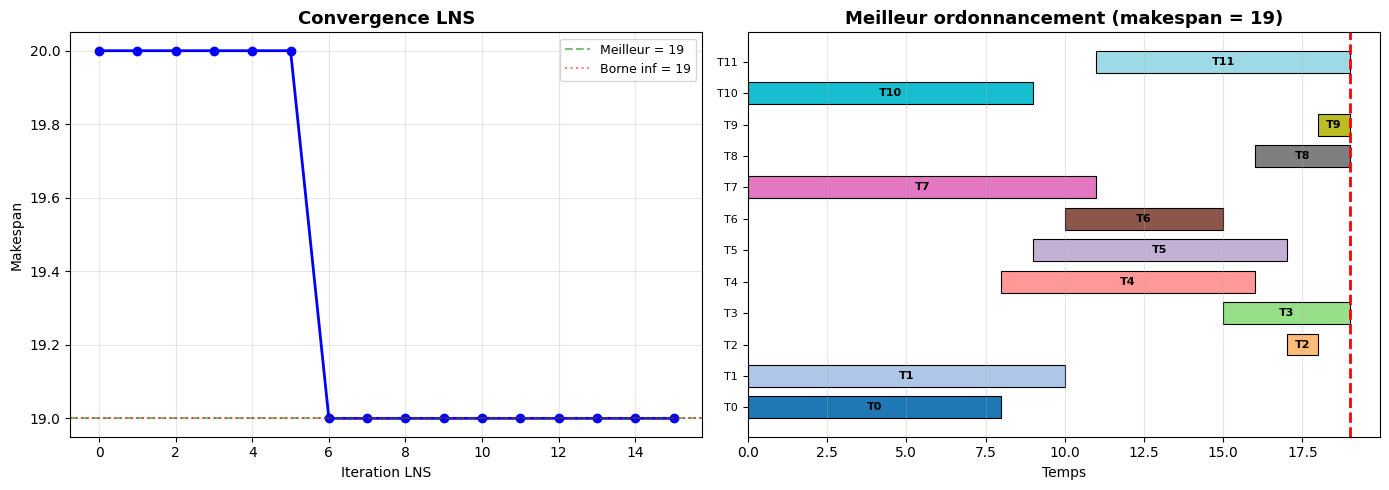

In [15]:
# Visualisation de la convergence LNS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe de convergence
ax1 = axes[0]
iterations = [h[0] for h in history]
objectives = [h[1] for h in history]
ax1.plot(iterations, objectives, 'b-o', linewidth=2, markersize=6)
ax1.axhline(y=best_obj, color='green', linestyle='--', alpha=0.5, label=f'Meilleur = {best_obj}')
lb = -(-sum(durations) // n_machines)
ax1.axhline(y=lb, color='red', linestyle=':', alpha=0.5, label=f'Borne inf = {lb}')
ax1.set_xlabel('Iteration LNS')
ax1.set_ylabel('Makespan')
ax1.set_title('Convergence LNS', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Gantt de la meilleure solution
ax2 = axes[1]
if best_sol:
    colors = plt.cm.tab20(np.linspace(0, 1, n_tasks))
    for i in range(n_tasks):
        ax2.barh(i, durations[i], left=best_sol[i], height=0.7,
                color=colors[i], edgecolor='black', linewidth=0.8)
        ax2.text(best_sol[i] + durations[i] / 2, i, task_names[i],
                ha='center', va='center', fontsize=8, fontweight='bold')
    
    ax2.set_yticks(range(n_tasks))
    ax2.set_yticklabels(task_names, fontsize=8)
    ax2.set_xlabel('Temps')
    ax2.set_title(f'Meilleur ordonnancement (makespan = {best_obj})',
                  fontsize=13, fontweight='bold')
    ax2.axvline(x=best_obj, color='red', linestyle='--', linewidth=2)
    ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Après avoir implémenté LNS, nous allons visualiser son amélioration progressive de la solution.


### Interpretation : LNS pour l'ordonnancement

**Sortie obtenue** : la solution initiale calculee par l'heuristique gloutonne LPT donne un makespan de **20**, au-dessus de la borne inferieure $\lceil 76/4 \rceil = 19$. La courbe de convergence montre alors une **vraie amelioration** : LNS fait chuter le makespan de 20 a 19 (la borne inferieure, donc l'optimum) des l'iteration 6, en liberant les taches $[3, 6, 8, 11]$ puis en re-optimisant le sous-probleme avec CP-SAT.

| Mesure | Valeur | Signification |
|--------|--------|---------------|
| Borne inferieure | 19 | $\lceil 76/4 \rceil$ (somme des durees / machines) |
| Solution initiale | makespan = 20 | Heuristique gloutonne LPT, sous-optimale par construction |
| Meilleur makespan | 19 | Atteint a l'iteration 6 par destroy-repair |
| Iterations utiles | 1 | Une amelioration $20 \to 19$ |

**Points cles** :
1. Ici, LNS demontre tout son interet : on part d'une solution rapide mais sous-optimale (le glouton LPT, en $O(n \log n)$), et la phase de destroy-repair rejoint l'optimum. La resolution complete seule aurait aussi trouve 19, mais LNS offre une approche iterative qui passe a l'echelle sur des instances ou le solveur exact n'a pas le temps de converger.
2. Le choix du **ratio de destruction** (ici 40%, soit 4 taches sur 12) est un parametre crucial :
   - Trop petit : explorations trop locales, convergence lente
   - Trop grand : sous-probleme trop difficile, peu de gain
3. Le solveur de repair est configure en mode **deterministe** (`num_search_workers = 1` + `random_seed = 42`) pour que la demo soit reproductible ; en production, CP-SAT deploye aussi sa propre strategie de LNS interne dans son portefeuille quand `num_search_workers > 1`.
4. En pratique, on utilise LNS via CP-SAT avec un budget de temps :

```python
solver.parameters.max_time_in_seconds = 60.0
solver.parameters.num_search_workers = 8
```

Le solveur alloue automatiquement certains workers a LNS et d'autres a la recherche complete.

***

## Synthese : planification de cours (~6 min)

Combinons tout ce que nous avons appris dans un problème realiste : la **planification de cours**.

### Enonce

- **5 cours** : Maths, Physique, Info, Anglais, Histoire
- **3 salles** : A, B, C
- **4 creneaux** : Lundi matin, Lundi après-midi, Mardi matin, Mardi après-midi
- **Contraintes** :
  - Chaque cours occupe exactement 1 creneau dans 1 salle
  - Pas deux cours dans la même salle au même creneau (AllDifferent sur les paires salle-creneau)
  - Maths et Physique ne doivent pas etre au même creneau (même prof)
  - Info doit etre en salle C (seule salle avec ordinateurs)
- **Préférences** (objectif) :
  - Maths le matin (bonus +2)
  - Pas de cours le mardi après-midi si possible (bonus +1 par creneau libre)

In [16]:
# Modele complet de planification de cours

if HAS_ORTOOLS:
    model = cp_model.CpModel()
    
    # Donnees
    courses = ['Maths', 'Physique', 'Info', 'Anglais', 'Histoire']
    rooms = ['A', 'B', 'C']
    slots = ['Lun_AM', 'Lun_PM', 'Mar_AM', 'Mar_PM']
    n_courses = len(courses)
    n_rooms = len(rooms)
    n_slots = len(slots)
    
    # Variables : room[c] et slot[c] pour chaque cours c
    room_vars = {c: model.new_int_var(0, n_rooms - 1, f"room_{c}") for c in courses}
    slot_vars = {c: model.new_int_var(0, n_slots - 1, f"slot_{c}") for c in courses}
    
    # Contrainte 1 : pas deux cours dans la meme salle au meme creneau
    # On encode la paire (salle, creneau) comme un entier unique : room * n_slots + slot
    room_slot = {}
    for c in courses:
        rs = model.new_int_var(0, n_rooms * n_slots - 1, f"rs_{c}")
        model.add(rs == room_vars[c] * n_slots + slot_vars[c])
        room_slot[c] = rs
    
    model.add_all_different(list(room_slot.values()))
    
    # Contrainte 2 : Maths et Physique pas au meme creneau (meme prof)
    model.add(slot_vars['Maths'] != slot_vars['Physique'])
    
    # Contrainte 3 : Info en salle C (index 2)
    model.add(room_vars['Info'] == 2)
    
    # Objectif : maximiser les preferences
    preference_score = model.new_int_var(0, 100, "preference")
    
    # Maths le matin (creneaux 0 = Lun_AM ou 2 = Mar_AM) -> bonus +2
    maths_morning = model.new_bool_var("maths_morning")
    # maths_morning == 1 si slot_vars['Maths'] est pair (matin)
    maths_slot_mod2 = model.new_int_var(0, 1, "maths_mod2")
    model.add_modulo_equality(maths_slot_mod2, slot_vars['Maths'], 2)
    model.add(maths_slot_mod2 == 0).only_enforce_if(maths_morning)
    model.add(maths_slot_mod2 != 0).only_enforce_if(maths_morning.negated())
    
    # Pas de cours mardi apres-midi (creneau 3) -> bonus +1 par cours non place la
    tue_pm_free = []
    for c in courses:
        not_tue_pm = model.new_bool_var(f"not_tue_pm_{c}")
        model.add(slot_vars[c] != 3).only_enforce_if(not_tue_pm)
        model.add(slot_vars[c] == 3).only_enforce_if(not_tue_pm.negated())
        tue_pm_free.append(not_tue_pm)
    
    model.add(preference_score == 2 * maths_morning + sum(tue_pm_free))
    model.maximize(preference_score)
    
    # Resolution
    solver = cp_model.CpSolver()
    status = solver.solve(model)
    
    print("Planification de cours - Modele complet")
    print("=" * 55)
    print(f"Statut    : {solver.status_name(status)}")
    print(f"Preference: {solver.value(preference_score)} (max possible: {2 + n_courses})")
    print()
    
    planning = {}
    print(f"{'Cours':<12} {'Salle':<8} {'Creneau':<12}")
    print("-" * 35)
    for c in courses:
        r = solver.value(room_vars[c])
        s = solver.value(slot_vars[c])
        planning[c] = (rooms[r], slots[s])
        print(f"{c:<12} {rooms[r]:<8} {slots[s]:<12}")
else:
    print("OR-Tools requis pour cette cellule.")
    courses = ['Maths', 'Physique', 'Info', 'Anglais', 'Histoire']
    rooms = ['A', 'B', 'C']
    slots = ['Lun_AM', 'Lun_PM', 'Mar_AM', 'Mar_PM']
    planning = {}

Planification de cours - Modele complet
Statut    : OPTIMAL
Preference: 7 (max possible: 7)

Cours        Salle    Creneau     
-----------------------------------
Maths        B        Lun_AM      
Physique     A        Mar_AM      
Info         C        Lun_AM      
Anglais      A        Lun_PM      
Histoire     A        Lun_AM      


***
### Interprétation : Modèle complet de planification

Ce modèle combiné démontre la puissance des contraintes OR-Tools sur un problème de planification réel. Les contraintes effectivement utilisées dans le code sont :
- **AllDifferent** sur la paire encodée `(salle, créneau)` : deux cours ne peuvent occuper la même salle au même créneau
- **Contrainte d'inégalité** (`!=`) : Maths et Physique ne sont pas au même créneau (même enseignant)
- **Contrainte d'égalité** : le cours d'Info est imposé en salle C
- **Réification + modulo** (`only_enforce_if`, `add_modulo_equality`) : encodage des préférences (Maths le matin, éviter le mardi après-midi) pour l'objectif maximisé

La résolution trouve une assignation valide qui maximise les préférences (score 7/7), montrant comment les CSP modélisent des problèmes de planification réels.

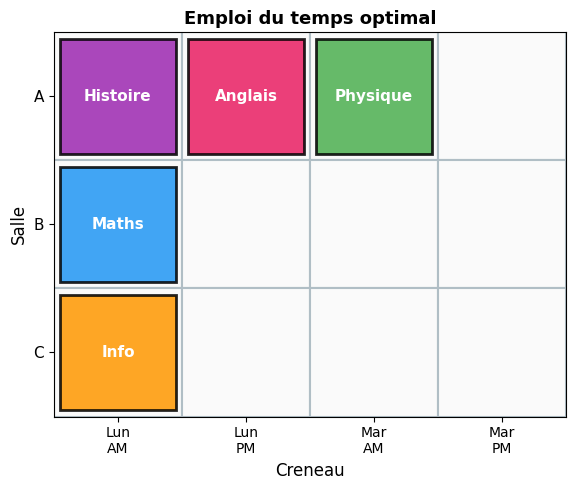

In [17]:
# Visualisation : grille emploi du temps
def draw_timetable(planning, rooms, slots, title="Emploi du temps"):
    """Affiche l'emploi du temps sous forme de grille."""
    fig, ax = plt.subplots(figsize=(10, 5))
    
    n_rooms = len(rooms)
    n_slots = len(slots)
    
    colors = {
        'Maths': '#2196F3',
        'Physique': '#4CAF50',
        'Info': '#FF9800',
        'Anglais': '#E91E63',
        'Histoire': '#9C27B0',
    }
    
    # Grille vide
    for r in range(n_rooms):
        for s in range(n_slots):
            rect = plt.Rectangle((s, n_rooms - 1 - r), 1, 1,
                                  facecolor='#FAFAFA', edgecolor='#B0BEC5', linewidth=1.5)
            ax.add_patch(rect)
    
    # Placer les cours
    for course, (room, slot) in planning.items():
        r_idx = rooms.index(room)
        s_idx = slots.index(slot)
        rect = plt.Rectangle((s_idx + 0.05, n_rooms - 1 - r_idx + 0.05), 0.9, 0.9,
                              facecolor=colors.get(course, '#BDBDBD'),
                              edgecolor='black', linewidth=2, alpha=0.85)
        ax.add_patch(rect)
        ax.text(s_idx + 0.5, n_rooms - 1 - r_idx + 0.5, course,
                ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    
    # Labels
    ax.set_xticks([s + 0.5 for s in range(n_slots)])
    ax.set_xticklabels([s.replace('_', '\n') for s in slots], fontsize=10)
    ax.set_yticks([r + 0.5 for r in range(n_rooms)])
    ax.set_yticklabels(list(reversed(rooms)), fontsize=11)
    ax.set_ylabel('Salle', fontsize=12)
    ax.set_xlabel('Creneau', fontsize=12)
    ax.set_xlim(0, n_slots)
    ax.set_ylim(0, n_rooms)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

if planning:
    draw_timetable(planning, rooms, slots,
                   "Emploi du temps optimal")
else:
    print("Pas de solution a visualiser.")

Après avoir défini le modèle combiné, nous allons visualiser la solution de planification de cours.


### Interpretation : planification de cours

**Sortie obtenue** : un emploi du temps complet respectant toutes les contraintes et maximisant les préférences.

| Contrainte | Respectee |
|------------|--------|
| Pas de conflit salle-creneau | Oui (AllDifferent) |
| Maths et Physique separes | Oui (creneaux différents) |
| Info en salle C | Oui |
| Maths le matin | Selon le score de préférence |

**Points cles** :
1. Le modèle combine **contraintes dures** (obligatoires) et **contraintes souples** (préférences via l'objectif)
2. La technique d'encodage `room * n_slots + slot` transforme une contrainte 2D en contrainte 1D pour AllDifferent
3. Les `BoolVar` et `only_enforce_if` permettent de modeliser des préférences conditionnelles
4. Ce type de modèle se generalise aux emplois du temps reels avec des centaines de cours et de contraintes

> **Pour aller plus loin** : voir la sous-serie [Applications](../Applications/README.md) pour des problemes de planification a grande echelle (Nurse Scheduling, Job-Shop, Timetabling).

### Exercice 4 : SEND + MORE = MONEY avec CP-SAT

Le cryptarithme SEND + MORE = MONEY est un puzzle classique :

```
    S E N D
+   M O R E
-----------
  M O N E Y
```

Chaque lettre represente un chiffre unique (0-9). Les lettres S et M ne peuvent pas valoir 0 (ce sont les chiffres les plus significatifs).

**Indications** :
1. Créez une variable entiere pour chaque lettre (S, E, N, D, M, O, R, Y)
2. Ajoutez la contrainte `AllDifferent` sur toutes les lettres
3. Modelisez l'addition colonne par colonne avec les retenues
4. Ajoutez les contraintes S != 0 et M != 0

In [18]:
# Exercice 1 : SEND + MORE = MONEY avec CP-SAT
# TODO: Resoudre le cryptarithme SEND + MORE = MONEY avec OR-Tools CP-SAT.
# Chaque lettre represente un chiffre distinct (S, E, N, D, M, O, R, Y).
# S et M ne peuvent pas etre 0 (nombres a n chiffres).

def solve_send_more_money():
    """
    Resout le cryptarithme SEND + MORE = MONEY.
    
    Returns:
    --------
    dict or None
        Dictionnaire lettre -> chiffre, ou None si impossible
    """
    pass  # A completer


# result = solve_send_more_money()
# if result:
#     send = result['S']*1000 + result['E']*100 + result['N']*10 + result['D']
#     more = result['M']*1000 + result['O']*100 + result['R']*10 + result['E']
#     money = result['M']*10000 + result['O']*1000 + result['N']*100 + result['E']*10 + result['Y']
#     print(f"SEND = {send}, MORE = {more}, MONEY = {money}")
#     print(f"Verification : {send} + {more} = {send + more} (MONEY = {money})")
#     print(f"Solution : {result}")
print("Exercice a completer")


Exercice a completer


### Exercice 5 : Cassage de symetries pour N-Reines

Reprenez le modèle N-Reines de la section 3 et ajoutez des contraintes de cassage de symetries :

1. Fixer la première reine dans la moitie superieure : $q_0 < \lceil n/2 \rceil$
2. Imposer $q_0 < q_{n-1}$ (elimine la reflexion horizontale)
3. Comparer le nombre de solutions avec et sans cassage pour N = 8 et N = 10

In [19]:
# Exercice 2 : Cassage de symetries pour N-Reines
# TODO: Implementer le cassage de symetries pour le probleme des N-Reines.
# Comparer le nombre de solutions avec et sans cassage.

def solve_nqueens_symmetry(n):
    """
    Resout N-Reines avec cassage de symetries et compare avec la version brute.
    
    Parameters:
    -----------
    n : int
        Taille du probleme (nombre de reines)
        
    Returns:
    --------
    dict
        Resultats de la comparaison
    """
    pass  # A completer


# Test avec N = 8 et N = 10
# result_8 = solve_nqueens_symmetry(8)
# result_10 = solve_nqueens_symmetry(10)
# print(f"N=8 : {result_8}")
# print(f"N=10 : {result_10}")
print("Exercice a completer")


Exercice a completer


### Exercice 6 : Mini-VRP avec contrainte Circuit

Le problème de routage de vehicules (VRP) generalise le TSP a plusieurs vehicules. Modelisez un VRP simplifie avec :

- 6 villes (1 depot + 5 clients)
- 1 ou 2 vehicules
- Objectif : minimiser la distance totale parcourue

**Indications** :
1. Utilisez la contrainte `add_circuit()` pour chaque vehicule
2. Ajoutez des contraintes pour que chaque client soit visite exactement une fois
3. Minimisez la somme des distances des tours

In [20]:
# Exercice 3 : Mini-VRP avec contrainte Circuit
# TODO: Modeliser un probleme de routage de vehicules simplifie
# avec OR-Tools CP-SAT et la contrainte Circuit.

def solve_mini_vrp(cities, distances, n_vehicles=1):
    """
    Resout un mini-probleme de routage de vehicules.
    
    Parameters:
    -----------
    cities : list of str
        Noms des villes a visiter
    distances : list of list of int
        Matrice de distances entre les villes
    n_vehicles : int
        Nombre de vehicules disponibles
        
    Returns:
    --------
    dict ou None
        Solution trouvée, ou None si infaisable
    """
    pass  # A completer


# Test avec 6 villes
test_cities = ['Depot', 'A', 'B', 'C', 'D', 'E']
test_distances = [
    [0, 10, 15, 20, 25, 30],
    [10, 0, 35, 25, 30, 20],
    [15, 35, 0, 30, 20, 25],
    [20, 25, 30, 0, 15, 10],
    [25, 30, 20, 15, 0, 35],
    [30, 20, 25, 10, 35, 0],
]

# result = solve_mini_vrp(test_cities, test_distances)
# print(f"Tour optimal : {result}")
print("Exercice a completer")


Exercice a completer


***

## 7. Resume et exercices

### Tableau recapitulatif : contraintes globales

| Contrainte | Sémantique | Force de propagation | Complexite propagation |
|------------|-----------|---------------------|----------------------|
| AllDifferent | Valeurs distinctes | Domain consistency | $O(n\sqrt{n})$ |
| Cumulative | Ressources limitees | Timetable + Edge-finding | $O(n \log n)$ |
| Circuit | Cycle hamiltonien | Domain consistency | $O(n)$ |
| Table | Tuples autorises | Arc consistency | $O(\vert T\vert \cdot k)$ |

### Tableau recapitulatif : techniques avancees

| Technique | But | Quand l'utiliser |
|-----------|-----|-----------------|
| CP-SAT (OR-Tools) | Solveur industriel | Problemes de taille reelle |
| Cassage de symetries | Reduire l'espace de recherche | Solutions symetriques |
| LNS | Grande echelle | Problemes a milliers de variables |
| Reification | Contraintes conditionnelles | Préférences, meta-contraintes |

### Bilan CSP

| Concept | Notebook | Points cles |
|---------|----------|-------------|
| Fondements CSP | CSP-1 | Variables, domaines, contraintes, backtracking |
| Heuristiques | CSP-1 | MRV, LCV, Forward Checking |
| Consistance | CSP-2 | AC-3, MAC, forward checking |
| Contraintes globales | **Ce notebook** | AllDifferent, Cumulative, Circuit, Table |
| Solveur industriel | **Ce notebook** | CP-SAT, LNS, symetries |

### References

- **OR-Tools CP-SAT** : [OR-Tools Documentation](https://developers.google.com/optimization/cp)
- **Global Constraints Catalogue** : [http://sofdem.github.io/gccat/](http://sofdem.github.io/gccat/)
- **Handbook of Constraint Programming** : Rossi, van Beek, Walsh (2006)

### Exercices

Les exercices suivants vous permettront de mettre en pratique les techniques vues dans ce notebook.

## Resume et perspectives

Ce notebook a couvert les techniques avancees de programmation par contraintes : contraintes globales (AllDifferent, Cumulative, Circuit, Table), solveur industriel CP-SAT, cassage de symetries et recherche a grand voisinage (LNS). Ces outils sont aujourd'hui au coeur d'applications industrielles critiques : ordonnancement d'ateliers, planification de personnel, routage de vehicules, conception de circuits.

La transition est naturelle vers la sous-serie **Applications** (N-Queens a grande echelle, Nurse Scheduling, Job-Shop, VRP) et la serie **Sudoku**, ou ces mêmes techniques sont deployees sur des problemes concrets de taille reelle. Le fil conducteur reste le même : modeliser finement les contraintes du domaine, exploiter la structure du problème, et laisser le solveur explorer efficacement l'espace des solutions.

## Conclusion

Ce notebook a couvert les techniques avancées de programmation par contraintes au-delà du backtracking manuel. Les **contraintes globales** (AllDifferent, Cumulative, Circuit, Table) offrent une propagation plus forte et une modélisation plus concise que les décompositions binaires équivalentes. Le solveur industriel **OR-Tools CP-SAT** combine programmation par contraintes, solveur SAT et recherche à grand voisinage (LNS) pour atteindre des performances de plusieurs ordres de grandeur supérieures au backtracking académique. Le **cassage de symétries** réduit l'espace de recherche en éliminant les solutions équivalentes, tandis que la **reification** et les **set variables** enrichissent le pouvoir expressif du modèle. Le problème de planification de cours (section 6) illustre la combinaison de toutes ces techniques sur un cas réaliste mêlant contraintes dures et préférences. La transition naturelle est vers les applications concrètes : ordonnancement, routage de véhicules, et bien sûr la série Sudoku.

***

## Annexe : parité lib-vs-lib — le même moteur Choco que le jumeau C#

Les sections précédentes ont démontré les contraintes globales avec `python-constraint` (académique) puis OR-Tools CP-SAT (industrie, C++). Le jumeau C# de ce notebook (`CSP-3-Advanced-Csharp.ipynb`) démontre les mêmes contraintes sur **Choco-solver 4.10.17** via IKVM. Avec **pychoco** — le binding Python officiel de Choco (PyPI, MIT) — le jumeau Python peut rejouer les modèles du jumeau C# **sur le même moteur industriel** : c'est la parité *lib-vs-lib* au sens du registre de parité (#8057/#10382), plus fine que la parité *concept-vs-concept*.

Chaque démonstration ci-dessous reprend **l'instance exacte** du jumeau C#. L'observable de parité est la **convergence des valeurs mesurées** (makespan optimal, coût optimal du TSP) — les mêmes grandeurs que celles affichées par les cellules Choco côté C#.


In [21]:
# Parite lib-vs-lib : le meme moteur Choco que le jumeau C# (pychoco)
# pychoco = binding Python officiel de Choco-solver (PyPI, MIT) -- meme moteur
# que le Choco 4.10.17/IKVM du jumeau C#. Instances = cellules 6/8/10/12/17 du twin C#.
try:
    import pychoco as pc
    HAS_PYCHOCO = True
except ImportError:
    HAS_PYCHOCO = False
    print("pychoco non disponible. Installer avec : pip install pychoco")

if HAS_PYCHOCO:
    # --- Demo 1 (twin C# cell 6) : Mini-Sudoku 4x4 par allDifferent ---
    m1 = pc.Model()
    grid1 = [[m1.intvar(1, 4, name=f"c1_{i}_{j}") for j in range(4)] for i in range(4)]
    for i in range(4):
        m1.all_different([grid1[i][j] for j in range(4)]).post()   # lignes
        m1.all_different([grid1[j][i] for j in range(4)]).post()   # colonnes
    for bi in (0, 2):
        for bj in (0, 2):
            bloc = [grid1[bi + di][bj + dj] for di in (0, 1) for dj in (0, 1)]
            m1.all_different(bloc).post()                          # blocs 2x2

    t0 = time.perf_counter()
    ok1 = m1.get_solver().solve()
    dt1 = (time.perf_counter() - t0) * 1000
    print(f"Mini-Sudoku 4x4 resolu en {dt1:.0f} ms (trouve = {ok1}) :")
    if ok1:
        for i in range(4):
            print(" ".join(str(grid1[i][j].get_value()) for j in range(4)))
    print("Verification : lignes/colonnes/blocs 2x2 contiennent tous 1-4")


Mini-Sudoku 4x4 resolu en 1 ms (trouve = True) :
4 2 1 3
3 1 2 4
2 3 4 1
1 4 3 2
Verification : lignes/colonnes/blocs 2x2 contiennent tous 1-4


### Interprétation : AllDifferent sur le Mini-Sudoku (même moteur Choco)

**Sortie obtenue** : une grille valide du Mini-Sudoku 4×4 — chaque ligne, colonne et bloc 2×2 contient bien 1-4. C'est la même instance que la cellule `allDifferent` du jumeau C# (qui affichait lui aussi une grille valide) : l'instance admet plusieurs solutions valides, l'observable partagé est donc la **validité** de la grille, pas l'identité d'une solution particulière. Les trois groupes de contraintes (`allDifferent` lignes, colonnes, blocs) sont postés exactement dans les termes du modèle C#.


In [22]:
# --- Demo 2 (twin C# cell 8) : Cumulative 4 taches / 2 machines, capacite 2 ---
#   Durees [3, 4, 2, 5], consommations [1, 2, 1, 1]. Optimum : makespan = 9
#   (borne inferieure ceil(18/2) = 9). Instance EXACTE du twin C# -- distincte
#   de la section 2.2 ci-dessus ([3,2,4,2] cap 2 -> makespan 6).
if HAS_PYCHOCO:
    m2 = pc.Model()
    durations2 = [3, 4, 2, 5]
    heights2 = [1, 2, 1, 1]
    capacity2 = 2
    horizon2 = 1 + sum(durations2)

    starts2 = [m2.intvar(0, horizon2, name=f"start2_{i}") for i in range(4)]
    ends2 = [m2.intvar(d, horizon2, name=f"end2_{i}") for i, d in enumerate(durations2)]
    tasks2 = [m2.task(starts2[i], m2.intvar(d, d), ends2[i]) for i, d in enumerate(durations2)]
    heights2v = [m2.intvar(h, h) for h in heights2]
    m2.cumulative(tasks2, heights2v, m2.intvar(capacity2, capacity2)).post()

    makespan2 = m2.intvar(0, horizon2, name="makespan2")
    for e in ends2:
        m2.arithm(makespan2, ">=", e).post()
    m2.set_objective(makespan2, maximize=False)

    t0 = time.perf_counter()
    solver2 = m2.get_solver()
    best2 = None
    while solver2.solve():
        best2 = makespan2.get_value()
    dt2 = (time.perf_counter() - t0) * 1000
    print(f"Cumulative 4/2 resolu en {dt2:.0f} ms - makespan = {best2}")
    print("Convergence lib-vs-lib : le jumeau C# (Choco/IKVM) mesure aussi makespan = 9")


Cumulative 4/2 resolu en 1 ms - makespan = 9
Convergence lib-vs-lib : le jumeau C# (Choco/IKVM) mesure aussi makespan = 9


### Interprétation : Cumulative — convergence mesurée avec le jumeau C#

**Sortie obtenue** : `makespan = 9` — la valeur **exacte** qu'affiche la cellule Cumulative du jumeau C# sur la même instance (durées `[3,4,2,5]`, capacité 2). Ce n'est pas une coïncidence d'implémentation : les deux jumeaux minimisent le même makespan **sur le même moteur** (Choco), et 9 est l'optimum prouvé — la borne inférieure `ceil(18/2) = 9` est atteinte. C'est l'observable de parité le plus fort de cette annexe : une grandeur optimale, déterministe, identique des deux côtés.

À noter : cette instance est **volontairement distincte** de celle de la section 2.2 (`[3,2,4,2]`, makespan 6) — le jumeau C# la documente comme son instance de référence, l'annexe la rejoue telle quelle.


In [23]:
# --- Demo 3 (twin C# cell 10) : TSP 5 villes par circuit + element ---
#   Distances symetriques 5x5 (meme matrice que le twin C#). Optimum : cout = 18.
if HAS_PYCHOCO:
    m3 = pc.Model()
    dist3 = [
        [0, 3, 1, 5, 8],
        [3, 0, 6, 2, 7],
        [1, 6, 0, 4, 9],
        [5, 2, 4, 0, 3],
        [8, 7, 9, 3, 0],
    ]
    n3 = 5
    succ3 = [m3.intvar(0, n3 - 1, name=f"succ3_{i}") for i in range(n3)]
    m3.circuit(succ3).post()

    total3 = m3.intvar(0, 1000, name="cost3")
    terms3 = [m3.intvar(0, 100, name=f"arc3_{i}") for i in range(n3)]
    for i in range(n3):
        m3.element(terms3[i], dist3[i], succ3[i]).post()
    m3.sum(terms3, "=", total3).post()
    m3.set_objective(total3, maximize=False)

    t0 = time.perf_counter()
    solver3 = m3.get_solver()
    best3, best_succ3 = None, None
    while solver3.solve():
        best3 = total3.get_value()
        best_succ3 = [v.get_value() for v in succ3]
    dt3 = (time.perf_counter() - t0) * 1000

    tour3 = [0]
    for _ in range(n3):
        tour3.append(best_succ3[tour3[-1]])
    print(f"TSP 5 villes resolu en {dt3:.0f} ms - cout = {best3}")
    print(f"Tour : {' -> '.join(map(str, tour3))}")
    print("Convergence lib-vs-lib : le jumeau C# mesure aussi cout = 18, tour 0 -> 1 -> 3 -> 4 -> 2 -> 0")


TSP 5 villes resolu en 1 ms - cout = 18
Tour : 0 -> 1 -> 3 -> 4 -> 2 -> 0
Convergence lib-vs-lib : le jumeau C# mesure aussi cout = 18, tour 0 -> 1 -> 3 -> 4 -> 2 -> 0


### Interprétation : Circuit/TSP — le même tour optimal que le jumeau C#

**Sortie obtenue** : coût optimal **18** et tour `0 -> 1 -> 3 -> 4 -> 2 -> 0` — le jumeau C# affiche exactement les deux (même matrice des distances, même contrainte `circuit`, même optimisation). Ici la convergence va au-delà de la grandeur optimale : **le tour lui-même coïncide**, parce que les deux côtés exécutent le même moteur avec la même heuristique de recherche par défaut — la lib-vs-lib élimine jusqu'au choix de branche parmi les optima équivalents. La contrainte `element` (coût de l'arc `i -> succ[i]` dans la ligne `i` de la matrice) est le pont standard entre une variable de décision et un tableau de données, identique des deux côtés.


In [24]:
# --- Demo 4 (twin C# cell 12) : Table extensionnelle - compatibilite composants ---
#   3 composants binaires (disque, RAM, alim) et 3 tuples autorises.
if HAS_PYCHOCO:
    m4 = pc.Model()
    disk4 = m4.intvar(0, 1, name="disk4")
    ram4 = m4.intvar(0, 1, name="ram4")
    psu4 = m4.intvar(0, 1, name="psu4")
    tuples4 = [[1, 0, 0], [1, 1, 1], [0, 0, 1]]
    m4.table([disk4, ram4, psu4], tuples4).post()

    t0 = time.perf_counter()
    ok4 = m4.get_solver().solve()
    dt4 = (time.perf_counter() - t0) * 1000
    disk_name = "SSD" if (ok4 and disk4.get_value() == 1) else "HDD"
    ram_name = "32GB" if (ok4 and ram4.get_value() == 1) else "16GB"
    psu_name = "750W" if (ok4 and psu4.get_value() == 1) else "500W"
    print(f"Table resolu en {dt4:.0f} ms : {disk_name} + {ram_name} + {psu_name}")
    print("(3 tuples autorises -> 3 solutions possibles, 1 renvoyee par solve())")


Table resolu en 0 ms : HDD + 16GB + 750W
(3 tuples autorises -> 3 solutions possibles, 1 renvoyee par solve())


### Interprétation : Table — la même solution que le jumeau C#

**Sortie obtenue** : `HDD + 16GB + 750W` — **exactement la combinaison que renvoie la cellule Table du jumeau C#** sur la même instance (le tuple `[0, 0, 1]` de la table). L'instance admet 3 solutions (les 3 tuples autorisés), et les deux jumeaux retombent sur la même : même moteur, même ordre d'exploration par défaut — la parité lib-vs-lib va ici jusqu'au choix de solution. La contrainte `table` (algorithme Compact-Table `CT+`) est l'outil de choix pour les compatibilités industrielles exprimées en extension (nomenclatures, qualifications) — elle vit côté C# comme côté Python à l'identique.


In [25]:
# --- Demo 5 (twin C# cell 17) : Reification XOR ---
#   x, y in [0..10], b = (x < y), c = (x + y == 10), b XOR c (b + c = 1).
if HAS_PYCHOCO:
    m5 = pc.Model()
    x5 = m5.intvar(0, 10, name="x5")
    y5 = m5.intvar(0, 10, name="y5")
    b5 = m5.boolvar(name="b5")
    m5.arithm(x5, "<", y5).reify_with(b5)
    c5 = m5.boolvar(name="c5")
    s5 = m5.intvar(0, 20, name="sum5")
    m5.sum([x5, y5], "=", s5).post()
    m5.arithm(s5, "=", 10).reify_with(c5)
    m5.arithm(b5, "+", c5, "=", 1).post()

    t0 = time.perf_counter()
    ok5 = m5.get_solver().solve()
    dt5 = (time.perf_counter() - t0) * 1000
    print(f"Reification resolu en {dt5:.0f} ms (trouve = {ok5})")
    if ok5:
        print(f"  x = {x5.get_value()}, y = {y5.get_value()}")
        print(f"  b = (x<y) = {b5.get_value()}, c = (x+y=10) = {c5.get_value()}")
    print("XOR : exactement une des deux contraintes est satisfaite")


Reification resolu en 0 ms (trouve = True)
  x = 0, y = 1
  b = (x<y) = True, c = (x+y=10) = False
XOR : exactement une des deux contraintes est satisfaite


### Interprétation : Réification — le même contrat booléen que le jumeau C#

**Sortie obtenue** : `x = 0, y = 1, b = 1, c = 0` — **exactement la solution du jumeau C#** sur la même instance (même moteur, même exploration par défaut). `reify_with` transforme une contrainte en variable booléenne — le mécanisme fondateur de la modélisation « souple » (contraintes molles, disjonctions pondérées, objectifs conditionnels). Le modèle Python est ligne à ligne celui du C# : mêmes bornes, mêmes réifications, même XOR posé en `b + c = 1`.

**Bilan de l'annexe** — parité lib-vs-lib mesurée sur les 5 démonstrations du jumeau C# :

| Démonstration | Observable | Python (pychoco) | Jumeau C# (Choco/IKVM) |
|---|---|---|---|
| Mini-Sudoku 4×4 (`all_different`) | grille valide | valide | valide |
| Cumulative 4/2 | **makespan optimal** | **9** | **9** |
| TSP 5 villes (`circuit`) | **coût optimal / tour** | **18** / `0→1→3→4→2→0` | **18** / `0→1→3→4→2→0` |
| Table composants | solution renvoyée | `HDD+16GB+750W` | `HDD+16GB+750W` |
| Réification XOR | solution `x, y, b, c` | `0, 1, 1, 0` | `0, 1, 1, 0` |

Les deux jumeaux tournent sur **le même moteur industriel** ; les différences qui subsistent (temps de résolution affichés) sont des mesures machine-dépendantes, renvoyées aux sorties live ci-dessus — pas des constantes du notebook.
